# Water-Intel Pipeline Walkthrough

This notebook walks you through every stage of the pipeline we've built so far:

1. **Raw data** — What comes from Environment Canada (ECCC)
2. **Processed data** — Cleaned, normalized, deduplicated (Day 5)
3. **Feature-engineered data** — Rolling stats, deltas, z-scores (Day 7)

Run each cell top-to-bottom to see the data transform at each step.

In [2]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib
import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)  # rebuild font cache if corrupted
import matplotlib.pyplot as plt

# Make sure project root is on the path
PROJECT_ROOT = Path.cwd().parent.parent  # water-intel/
ML_ROOT = PROJECT_ROOT / "ml"
sys.path.insert(0, str(ML_ROOT))

print(f"Project root: {PROJECT_ROOT}")
print(f"ML root:      {ML_ROOT}")

Project root: c:\_GIT\water-intel
ML root:      c:\_GIT\water-intel\ml


## Stage 1: Raw Data — What comes from ECCC

This is the original CSV from Environment Canada. It has their column naming conventions and hasn't been cleaned yet.

In [2]:
# Load the raw sample data — this is what ECCC gives us
raw = pd.read_csv(PROJECT_ROOT / "data" / "sample" / "sample_water_quality.csv")
print(f"Raw data: {raw.shape[0]} rows × {raw.shape[1]} columns")
print(f"\nColumn names (ECCC format):")
print(raw.columns.tolist())
raw.head()

Raw data: 13116 rows × 12 columns

Column names (ECCC format):
['site_no', 'sample_datetime', 'qualifier_flag', 'value', 'sdl', 'mdl', 'variable_code', 'unit', 'variable', 'variable_fr', 'qa_status', 'sample_id']


,site_no,sample_datetime,qualifier_flag,value,sdl,mdl,variable_code,unit,variable,variable_fr,qa_status,sample_id
0,BC08NL0001,2000-01-11 09:15:00,NaN,0.0003,0.0001,NaN,100250,MG/L,ARSENIC TOTAL,ARSENIC TOTAL,P,00PY000115
1,BC08NL0001,2000-01-11 09:15:00,<,0.0002,0.0002,NaN,100228,MG/L,LEAD TOTAL,PLOMB TOTAL,P,00PY000115
2,BC08NL0001,2000-01-11 09:15:00,NaN,136.0000,2.0000,NaN,2041,µS/CM,SPECIFIC CONDUCTANCE,CONDUCTANCE SPÉCIFIQUE,V,00PY000115
3,BC08NL0001,2000-01-11 09:15:00,NaN,-1.0000,NaN,NaN,1125,DEG C,TEMPERATURE (WATER),TEMPÉRATURE (EAU),P,00PY000115
4,BC08NL0001,2000-01-11 09:15:00,NaN,0.4400,0.0500,NaN,2074,NTU,TURBIDITY,TURBIDITÉ,V,00PY000115


In [3]:
# What water quality parameters are measured?
print("Water quality parameters measured:")
for i, v in enumerate(raw["variable"].unique(), 1):
    print(f"  {i:2d}. {v}")

print(f"\nMonitoring stations: {raw['site_no'].unique()}")
print(f"Date range: {raw['sample_datetime'].min()} → {raw['sample_datetime'].max()}")

Water quality parameters measured:
   1. ARSENIC TOTAL
   2. LEAD TOTAL
   3. SPECIFIC CONDUCTANCE
   4. TEMPERATURE (WATER)
   5. TURBIDITY
   6. FECAL COLIFORMS
   7. ARSENIC DISSOLVED
   8. LEAD DISSOLVED
   9. PHOSPHORUS TOTAL
  10. DISSOLVED NITRITE/NITRATE
  11. PH (FIELD)
  12. ESCHERICHIA COLI

Monitoring stations: ['BC08NL0001' 'BC08NL0005' 'BC08NM0001' 'BC08NM0160']
Date range: 2000-01-11 09:15:00 → 2025-11-26 07:27:00


## Stage 2: Ingestion — Load + Validate (Day 4)

The `ECCCLoader` class loads the raw CSV, validates it has all required columns, parses dates, and renames columns to our normalized schema (`site_no` → `station_id`, `sample_datetime` → `timestamp`, etc.).

In [4]:
# Run the ECCC Loader — this is what Day 4 built
from src.ingest.eccc_loader import ECCCLoader
from src.ingest.schema import COLUMN_MAPPING

print("Column renaming (raw → normalized):")
for raw_col, norm_col in COLUMN_MAPPING.items():
    print(f"  {raw_col:20s} → {norm_col}")

# Load and process
loader = ECCCLoader(PROJECT_ROOT / "data" / "sample" / "sample_water_quality.csv")
loaded = loader.process()
print(f"\nAfter ingestion: {loaded.shape[0]} rows × {loaded.shape[1]} columns")
print(f"Columns now: {loaded.columns.tolist()}")
loaded.head()

Column renaming (raw → normalized):
  site_no              → station_id
  sample_datetime      → timestamp
  variable             → parameter
  value                → value
  unit                 → unit
  qualifier_flag       → qualifier
  qa_status            → qa_status
  sample_id            → sample_id

After ingestion: 13116 rows × 8 columns
Columns now: ['station_id', 'timestamp', 'parameter', 'value', 'unit', 'qualifier', 'qa_status', 'sample_id']


,station_id,timestamp,parameter,value,unit,qualifier,qa_status,sample_id
0,BC08NL0001,2000-01-11 09:15:00,ARSENIC TOTAL,0.0003,MG/L,NaN,P,00PY000115
1,BC08NL0001,2000-01-11 09:15:00,LEAD TOTAL,0.0002,MG/L,<,P,00PY000115
2,BC08NL0001,2000-01-11 09:15:00,SPECIFIC CONDUCTANCE,136.0000,µS/CM,NaN,V,00PY000115
3,BC08NL0001,2000-01-11 09:15:00,TEMPERATURE (WATER),-1.0000,DEG C,NaN,P,00PY000115
4,BC08NL0001,2000-01-11 09:15:00,TURBIDITY,0.4400,NTU,NaN,V,00PY000115


## Stage 3: Processed Data — Clean + Dedup + Normalize (Day 5)

`build_processed.py` takes the ingested data and:
- Drops rows with null required fields
- Removes exact duplicates
- Normalizes timestamps to ISO-8601
- Sorts deterministically

The output is saved to `data/processed/eccc_processed.csv`.

In [5]:
# Load the processed output from Day 5
processed = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "eccc_processed.csv",
    parse_dates=["timestamp"]
)

print(f"Processed data: {processed.shape[0]} rows × {processed.shape[1]} columns")
print(f"Stations: {processed['station_id'].nunique()}")
print(f"Parameters: {processed['parameter'].nunique()}")
print(f"Date range: {processed['timestamp'].min()} → {processed['timestamp'].max()}")
print(f"Nulls in required columns: {processed[['station_id','timestamp','parameter','value','unit']].isnull().sum().sum()}")
print(f"Duplicates: {processed.duplicated().sum()}")
processed.head()

Processed data: 13116 rows × 8 columns
Stations: 4
Parameters: 12
Date range: 2000-01-11 09:15:00 → 2025-11-26 07:27:00
Nulls in required columns: 0
Duplicates: 0


,station_id,timestamp,parameter,value,unit,qualifier,qa_status,sample_id
0,BC08NL0001,2000-01-11 09:15:00,ARSENIC TOTAL,0.0003,MG/L,NaN,P,00PY000115
1,BC08NL0001,2000-01-11 09:15:00,LEAD TOTAL,0.0002,MG/L,<,P,00PY000115
2,BC08NL0001,2000-01-11 09:15:00,SPECIFIC CONDUCTANCE,136.0000,µS/CM,NaN,V,00PY000115
3,BC08NL0001,2000-01-11 09:15:00,TEMPERATURE (WATER),-1.0000,DEG C,NaN,P,00PY000115
4,BC08NL0001,2000-01-11 09:15:00,TURBIDITY,0.4400,NTU,NaN,V,00PY000115


In [6]:
# How many readings per station per parameter?
counts = processed.groupby(["station_id", "parameter"]).size().unstack(fill_value=0)
print("Readings per station × parameter:\n")
counts

Readings per station × parameter:



parameter,ARSENIC DISSOLVED,ARSENIC TOTAL,DISSOLVED NITRITE/NITRATE,ESCHERICHIA COLI,FECAL COLIFORMS,LEAD DISSOLVED,LEAD TOTAL,PH (FIELD),PHOSPHORUS TOTAL,SPECIFIC CONDUCTANCE,TEMPERATURE (WATER),TURBIDITY
station_id,,,,,,,,,,,,
BC08NL0001,318,644,183,0,653,306,643,0,501,659,419,662
BC08NL0005,306,611,172,0,587,292,602,0,471,627,395,628
BC08NM0001,36,339,172,0,410,36,418,1,401,424,292,426
BC08NM0160,37,56,0,60,1,37,56,55,58,61,0,61


## Stage 4: Feature Engineering (Day 7 — Today!)

`build_features.py` adds ML-ready columns per station+parameter:
- **delta** — how much did the value change since last reading?
- **time_gap_days** — how many days between readings?
- **rate_of_change** — delta normalized by time (handles irregular sampling)
- **is_gap** — flag if a long gap (>35 days) occurred
- **rolling_mean / rolling_std** — smoothed averages over 7, 14, 30 readings
- **zscore** — how unusual is this reading compared to recent history?

These features are what the anomaly model (Day 8) will consume.

In [7]:
# Load the feature-engineered output
features = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "eccc_features.csv",
    parse_dates=["timestamp"]
)

print(f"Feature data: {features.shape[0]} rows × {features.shape[1]} columns")
print(f"\nOriginal columns (from processed): station_id, timestamp, parameter, value, unit, qualifier, qa_status, sample_id")
print(f"\nNew feature columns added:")
feature_cols = ["delta", "time_gap_days", "rate_of_change", "is_gap",
                "rolling_mean_7", "rolling_std_7", "rolling_mean_14", "rolling_std_14",
                "rolling_mean_30", "rolling_std_30", "zscore"]
for col in feature_cols:
    nan_pct = features[col].isna().mean() * 100
    print(f"  {col:25s}  NaN: {nan_pct:.1f}%")

features.head(10)

Feature data: 13116 rows × 19 columns

Original columns (from processed): station_id, timestamp, parameter, value, unit, qualifier, qa_status, sample_id

New feature columns added:
  delta                      NaN: 0.3%
  time_gap_days              NaN: 0.3%
  rate_of_change             NaN: 0.3%
  is_gap                     NaN: 0.0%
  rolling_mean_7             NaN: 0.0%
  rolling_std_7              NaN: 0.3%
  rolling_mean_14            NaN: 0.0%
  rolling_std_14             NaN: 0.3%
  rolling_mean_30            NaN: 0.0%
  rolling_std_30             NaN: 0.3%
  zscore                     NaN: 0.5%


,station_id,timestamp,parameter,value,unit,qualifier,qa_status,sample_id,delta,time_gap_days,rate_of_change,is_gap,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14,rolling_mean_30,rolling_std_30,zscore
0,BC08NL0001,2000-06-27 09:20:00,ARSENIC DISSOLVED,0.0004,MG/L,NaN,P,00PY003671,NaN,NaN,NaN,0,0.000400,NaN,0.000400,NaN,0.000400,NaN,NaN
1,BC08NL0001,2002-04-16 16:00:00,ARSENIC DISSOLVED,0.0004,MG/L,NaN,P,03PY000179,0.0000,658.277778,0.000000e+00,1,0.000400,0.000000,0.000400,0.000000,0.000400,0.000000,NaN
2,BC08NL0001,2002-05-14 09:10:00,ARSENIC DISSOLVED,0.0004,MG/L,NaN,P,03PY000213,0.0000,27.715278,0.000000e+00,0,0.000400,0.000000,0.000400,0.000000,0.000400,0.000000,NaN
3,BC08NL0001,2002-05-28 09:10:00,ARSENIC DISSOLVED,0.0003,MG/L,NaN,P,03PY000236,-0.0001,14.000000,-7.142857e-06,0,0.000375,0.000050,0.000375,0.000050,0.000375,0.000050,-1.500000
4,BC08NL0001,2002-06-11 09:15:00,ARSENIC DISSOLVED,0.0002,MG/L,<,P,03PY000254,-0.0001,14.003472,-7.141086e-06,0,0.000340,0.000089,0.000340,0.000089,0.000340,0.000089,-1.565248
5,BC08NL0001,2002-06-25 08:45:00,ARSENIC DISSOLVED,0.0003,MG/L,NaN,P,03PY000280,0.0001,13.979167,7.153502e-06,0,0.000333,0.000082,0.000333,0.000082,0.000333,0.000082,-0.408248
6,BC08NL0001,2002-11-26 09:10:00,ARSENIC DISSOLVED,0.0002,MG/L,NaN,P,03PY000680,-0.0001,154.017361,-6.492775e-07,1,0.000314,0.000090,0.000314,0.000090,0.000314,0.000090,-1.270215
7,BC08NL0001,2002-12-09 09:10:00,ARSENIC DISSOLVED,0.0002,MG/L,NaN,P,03PY000618,0.0000,13.000000,0.000000e+00,0,0.000286,0.000090,0.000300,0.000093,0.000300,0.000093,-1.080123
8,BC08NL0001,2003-02-18 08:10:00,ARSENIC DISSOLVED,0.0002,MG/L,NaN,P,03PY000439,0.0000,70.958333,0.000000e+00,1,0.000257,0.000079,0.000289,0.000093,0.000289,0.000093,-0.957895
9,BC08NL0001,2003-05-27 09:15:00,ARSENIC DISSOLVED,0.4000,µG/L,NaN,P,03PY001130,0.3998,98.045139,4.077714e-03,1,0.057343,0.151098,0.040260,0.126400,0.040260,0.126400,2.846049


In [8]:
# Zoom into one station + one parameter to see features in action
station = "BC08NL0001"
param = "TURBIDITY"
sub = features[(features["station_id"] == station) & (features["parameter"] == param)].copy()

print(f"Station {station} — {param}: {len(sub)} readings")
sub[["timestamp", "value", "delta", "rate_of_change", "rolling_mean_30", "zscore", "is_gap"]].head(15)

Station BC08NL0001 — TURBIDITY: 662 readings


,timestamp,value,delta,rate_of_change,rolling_mean_30,zscore,is_gap
4326,2000-01-11 09:15:00,0.44,NaN,NaN,0.440000,NaN,0
4327,2000-01-25 12:15:00,0.43,-0.01,-0.000708,0.435000,-0.707107,0
4328,2000-02-09 10:25:00,0.38,-0.05,-0.003350,0.416667,-1.140647,0
4329,2000-02-22 08:30:00,0.54,0.16,0.012384,0.447500,1.380187,0
4330,2000-03-07 14:25:00,0.68,0.14,0.009827,0.494000,1.561978,0
4331,2000-03-21 08:55:00,1.30,0.62,0.045023,0.628333,1.942039,0
4332,2000-04-04 12:15:00,13.00,11.70,0.827505,2.395714,2.262635,0
4333,2000-04-18 12:15:00,5.90,-7.10,-0.507143,2.833750,0.679508,0
4334,2000-05-02 12:45:00,5.67,-0.23,-0.016404,3.148889,0.582835,0
4335,2000-05-16 10:10:00,3.50,-2.17,-0.156201,3.184000,0.077456,0


## Visualize: Turbidity with Z-Score Highlights

The **z-score** tells us how unusual a reading is. Readings with |zscore| > 2 are potential anomalies — the kind of spikes the ML model will learn to flag.

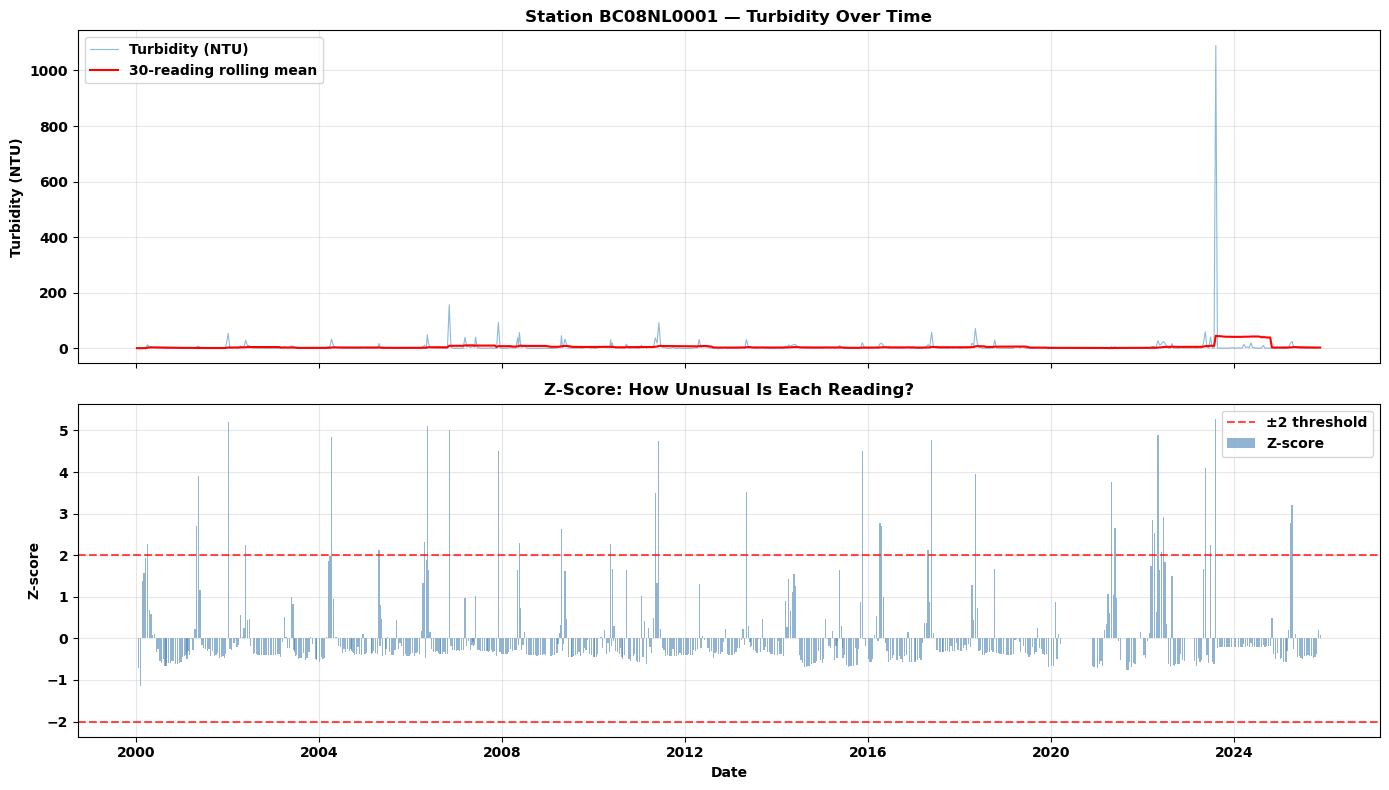


🔴 Readings with |z-score| > 2: 35 out of 662 (5.3%)


In [9]:
# Plot turbidity readings with z-score anomaly highlights
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top: Raw value + rolling mean
ax1.plot(sub["timestamp"], sub["value"], alpha=0.5, linewidth=0.8, label="Turbidity (NTU)")
ax1.plot(sub["timestamp"], sub["rolling_mean_30"], color="red", linewidth=1.5, label="30-reading rolling mean")
ax1.set_ylabel("Turbidity (NTU)")
ax1.set_title(f"Station {station} — Turbidity Over Time")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Bottom: Z-score — highlight |z| > 2
ax2.bar(sub["timestamp"], sub["zscore"], width=10, alpha=0.6, color="steelblue", label="Z-score")
ax2.axhline(y=2, color="red", linestyle="--", alpha=0.7, label="±2 threshold")
ax2.axhline(y=-2, color="red", linestyle="--", alpha=0.7)
ax2.set_ylabel("Z-score")
ax2.set_xlabel("Date")
ax2.set_title("Z-Score: How Unusual Is Each Reading?")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Count anomalous readings
n_anomalous = (sub["zscore"].abs() > 2).sum()
print(f"\n🔴 Readings with |z-score| > 2: {n_anomalous} out of {len(sub)} ({n_anomalous/len(sub)*100:.1f}%)")

## Visualize: Compare Multiple Parameters

Let's look at a few key water quality signals side by side for one station.

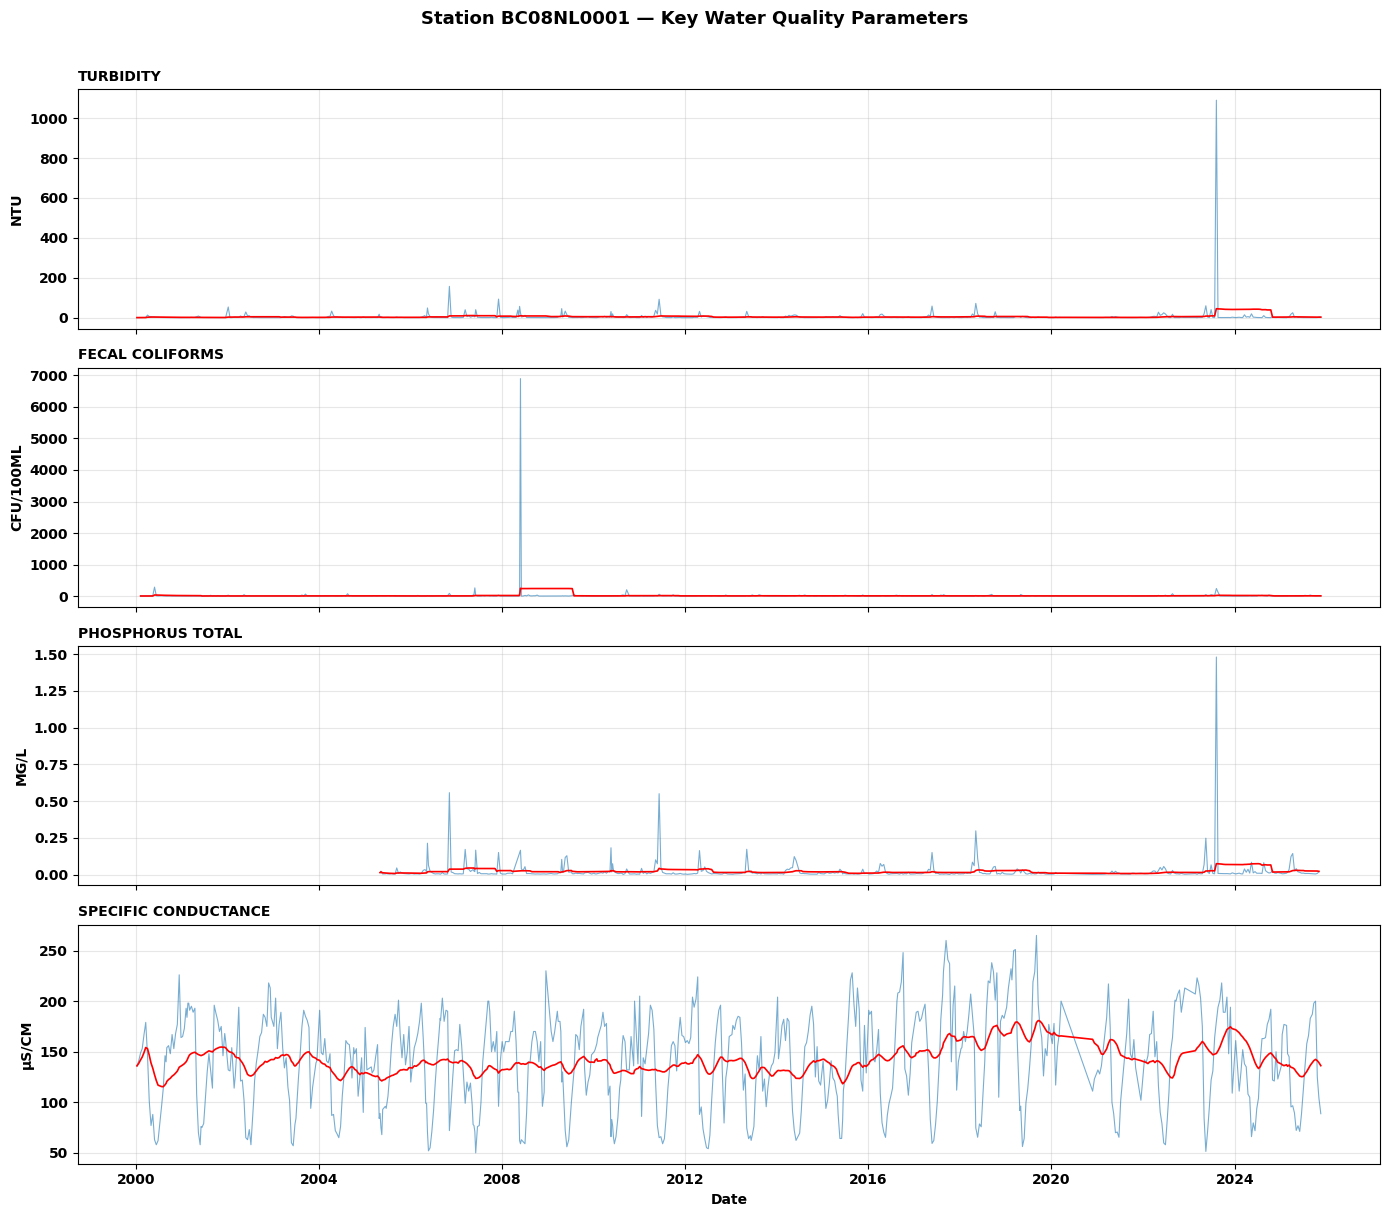

In [10]:
# Compare key parameters for station BC08NL0001
key_params = ["TURBIDITY", "FECAL COLIFORMS", "PHOSPHORUS TOTAL", "SPECIFIC CONDUCTANCE"]
station_data = features[features["station_id"] == station]

fig, axes = plt.subplots(len(key_params), 1, figsize=(14, 12), sharex=True)

for ax, param in zip(axes, key_params):
    psub = station_data[station_data["parameter"] == param]
    ax.plot(psub["timestamp"], psub["value"], alpha=0.6, linewidth=0.8)
    ax.plot(psub["timestamp"], psub["rolling_mean_30"], color="red", linewidth=1.2)
    ax.set_ylabel(psub["unit"].iloc[0] if len(psub) > 0 else "")
    ax.set_title(param, fontsize=10, loc="left")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Date")
fig.suptitle(f"Station {station} — Key Water Quality Parameters", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## What's Next?

The pipeline so far:

```
✅ Raw CSV → ✅ Ingest/Validate → ✅ Process → ✅ Features → ❓ Anomaly Model → ❓ Risk Score → ❓ API → ❓ Dashboard
```

**Day 8** will feed these features into an **Isolation Forest** anomaly detector that flags unusual readings — the core "early warning" signal. Everything after that is about scoring, serving, and visualizing the results.

Try changing `station` and `param` variables above to explore different stations and water quality parameters!